In [22]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [23]:
from langchain_core.tools import Tool
from langchain_community.utilities import GoogleSerperAPIWrapper

tools = []

serper = GoogleSerperAPIWrapper()
tool_search = Tool(
        name="search",
        func=serper.run,
        description="Use this tool when you want to get the results of an online web search"
    )

tools.append(tool_search)

In [24]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

def build_vectorstore(urls: list[str], persist_dir: str = "./chroma_db"):
    docs = []
    for url in urls:
        loader = PyPDFLoader(url)
        docs.extend(loader.load())

    splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
    chunks = splitter.split_documents(docs)

    return Chroma.from_documents(chunks, OpenAIEmbeddings(), persist_directory=persist_dir)

In [25]:
def load_vectorstore(persist_dir: str = "./chroma_db"):
    return Chroma(persist_directory=persist_dir, embedding_function=OpenAIEmbeddings())

In [26]:
urls = [
    # Mathematics
    "https://static.data.gouv.fr/resources/programmes-denseignement-de-terminale-generale-reforme-du-baccalaureat-2021/20190830-150235/mene1921264a-spe264-annexe-1158825.pdf",
    "https://static.data.gouv.fr/resources/programmes-denseignement-de-terminale-generale-reforme-du-baccalaureat-2021/20190830-150235/mene1921265a-spe265-annexe-1159134.pdf",
    "https://static.data.gouv.fr/resources/programmes-denseignement-de-terminale-generale-reforme-du-baccalaureat-2021/20190830-150230/mene1921246a-spe246-annexe-1158907.pdf",
    # Physics
    "https://static.data.gouv.fr/resources/programmes-denseignement-de-terminale-generale-reforme-du-baccalaureat-2021/20190830-150230/mene1921249a-spe249-annexe-1158929.pdf",
    # SVT
    "https://static.data.gouv.fr/resources/programmes-denseignement-de-terminale-generale-reforme-du-baccalaureat-2021/20190830-150231/mene1921252a-spe252-annexe-1159114.pdf"
]
build_vectorstore(urls)

In [27]:
from langchain_core.tools import create_retriever_tool

vectorstore = load_vectorstore()  # or build_vectorstore(urls) on first run
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

retriever_tool = create_retriever_tool(
    retriever,
    name="search_school_programs",
    description="Recherche des informations dans les documents PDF du programme du baccalauréat. Utiliser cet outil pour trouver des notions, des thèmes ou des éléments du programme"
)

tools.append(retriever_tool)

/tmp/ipykernel_3586/2005763026.py:2: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  return Chroma(persist_directory=persist_dir, embedding_function=OpenAIEmbeddings())


In [28]:
from typing import Annotated, Optional, TypedDict, List, Any
from langgraph.graph import add_messages
from pydantic import BaseModel, Field

class SubPartPlan(BaseModel):
    title: str = Field(description="le titre de la sous partie")
    content: str = Field(description="le contenu détaillé de cette sous partie")
    diagram: Optional[str] = Field(description="la description d'un diagramme servant à illustrer cette sous partie")

class PartPlan(BaseModel):
    title: str = Field(description="le titre de la partie")
    time: str = Field(description="le temps associé à cette partie")
    topics: List[str] = Field(description="la liste des éléments du programme de terminale scientifique auquel cette partie se rattache, contenant le nom du document et la section correspondante")
    content: str = Field(description="Un résumé du contenu de cette partie")
    subparts: List[SubPartPlan] = Field(description="la liste des sous-chapitres qui constituent cette partie")

class GrandOralPlan(BaseModel):
    parts: List[PartPlan] = Field(description="la liste des parties du plan de l'exposé pour le grand oral du bac")


class State(TypedDict):
    messages: Annotated[List[Any], add_messages]
    subject: str
    pros: List[str]
    cons: List[str]
    topics: List[str]
    is_valid: bool
    plan: Optional[GrandOralPlan]
    diagram_titles: List[str]
    diagram_urls: List[str]

GRAND_ORAL_DURATION = 10 # in minutes


In [29]:
import base64
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from pydantic import BaseModel, Field

class EvaluationResult(BaseModel):
    topics: List[str] = Field(description="la liste des éléments du programme auquel le sujet se rattache avec le nom du document de référence et le numéro de page")
    is_valid: bool = Field(description="Ce sujet est il un bon sujet pour le grand oral?")

class ProsArguments(BaseModel):
    pros: List[str] = Field(description="La liste des arguments pour le sujet du grand oral")

class ConsArguments(BaseModel):
    cons: List[str] = Field(description="La liste des arguments contre le sujet du grand oral")

teacher_llm = ChatOpenAI(model="gpt-4o-mini")
teacher_llm_with_tools = teacher_llm.bind_tools(tools)  # for tool calling
tool_node = ToolNode(tools)                              # for executing tool calls

In [30]:
from langchain_core.messages import HumanMessage, SystemMessage


def run_with_tools(messages: list) -> list:
    """Run the LLM in a loop until it stops calling tools."""
    while True:
        response = teacher_llm_with_tools.invoke(messages)
        messages = messages + [response]
        if not response.tool_calls:
            break
        tool_results = tool_node.invoke({"messages": messages})
        messages = messages + tool_results["messages"]  # append, don't replace
    return messages


def evaluate_topic(relevant: bool, state: State) -> State:
    pros_or_cons = "arguments pour" if relevant else "arguments contre"
    system_message = f"Vous êtes un professeur de lycée de terminale, qui connait parfaitement le programme de mathématiques et de physique chimie de terminale. \
    Votre rôle est d'évaluer les sujets pour le grand oral du bac, en tenant compte des contraintes suivantes: \
    - Le sujet doit être en lien avec les programmes de terminale scientifique, notamment en mathématiques et en physique-chimie\
    - Le sujet doit permettre à l'élève de démontrer sa capacité à construire une argumentation solide et à présenter des connaissances précises.\
    - Le sujet doit être suffisamment large pour permettre une exploration approfondie, mais pas trop vaste pour éviter la superficialité.\
    - Le sujet doit être original et susciter l'intérêt de l'élève, tout en restant pertinent par rapport aux thématiques abordées en terminale scientifique. \
    Votre réponse doit contenir une liste qui donnent les {pros_or_cons}"

    messages = [
        SystemMessage(content=system_message),
        HumanMessage(content=f"Evaluer le sujet suivant: {state['subject']}")
    ]

    # Pass 1: let the LLM call tools freely
    messages = run_with_tools(messages)

    # Pass 2: extract structured output from enriched context
    if relevant:
        result: ProsArguments = teacher_llm.with_structured_output(ProsArguments).invoke(messages)
        return {"pros": result.pros}
    else:
        result: ConsArguments = teacher_llm.with_structured_output(ConsArguments).invoke(messages)
        return {"cons": result.cons}


def evaluate_topic_relevant(state: State) -> State:
    return evaluate_topic(True, state)

def evaluate_topic_not_relevant(state: State) -> State:
    return evaluate_topic(False, state)

def judge_topic(state: State) -> State:
    system_message = "Vous êtes un professeur de lycée de terminale, qui connait parfaitement le programme de mathématiques et de physique chimie de terminale. \
    Votre rôle est d'évaluer un sujet pour le grand oral. Vous prenez en compte les arguments Pour et Contre qui vous sont fournis. A partir de ces arguments, vous effectuez une liste des liens avec les programmes scolaires. " \
    "Pour chaque élément du programme que vous identifiez, vous validez qu'il fait bien partie du programme en vérifiant sa présence dans les documents de référence à l'aide de l'outil search_school_programs. " \
    "S'ils ne sont pas présents, vous ne les ajoutez pas dans la liste. " \
    "S'ils sont présents, vous les ajoutez avec le nom du ducument de référence ainsi que le numéro de page"

    messages = [
        SystemMessage(content=system_message),
        HumanMessage(content=f"Évaluez le sujet: {state['subject']} en tenant compte des arguments Pour: {state['pros']} et Contre: {state['cons']}")
    ]

    messages = run_with_tools(messages)

    result: EvaluationResult = teacher_llm.with_structured_output(EvaluationResult).invoke(messages)
    return {"topics": result.topics, "is_valid": result.is_valid}

In [31]:
from openai import OpenAI

student_llm = ChatOpenAI(model="gpt-5.4").with_structured_output(GrandOralPlan)
image_client = OpenAI()

def generate_plan_for_topic(state: State) -> dict:
    system_message = "Vous êtes un brillant élève de terminale scientifique, et vous préparez le plan de votre grand oral du baccalauréat."
    user_message = f"Le sujet que vous avez choisi est {state['subject']}\
    Les points importants qui valident ce sujet sont les suivants: {state['pros']}\
    Les points de vigilance sont les suivants: {state['cons']}\
    Les sujets du programme auquel il se rattache sont les suivants: {state['topics']}\
    Ecrire le plan de l'exposé en décrivant les chacune des parties cet exposé avec :\
    - le titre\
    - un résumé du contenu\
    - le temps de cette partie\
    - les sujets du programme qui sont abordés\
    - la liste de chacune des sous parties contenant elles mêmes:le titre, le contenu et éventuellement la description d'un diagramme servant à l'illustrer.\
    Le plan doit contenir au minimum 3 parties, avec une introduction et une conclusion. Le total du temps des différentes parties doit être de {GRAND_ORAL_DURATION} minutes"

    messages = [
        SystemMessage(content=system_message),
        HumanMessage(content=user_message)]
    eval_result: GrandOralPlan = student_llm.invoke(messages)
    return {"plan": eval_result}


def generate_image(state: State) -> dict:
    subject = state.get("subject", "")
    plan: GrandOralPlan = state.get("plan")

    if not plan:
        return {"diagram_titles": [], "diagram_urls": []}

    descriptions = [
        (subpart.title, subpart.diagram)
        for part in plan.parts
        for subpart in part.subparts
        if subpart.diagram
    ]

    titles, urls = [], []
    for title, description in descriptions:
        prompt = (
            f"Diagramme d'illustration pour le grand oral du bac. Ce diagramme doit pouvoir être dessiné à la main par l'élève lors de la préparation de sa présentation. "
            f"Sujet du grand oral: {subject}. "
            f"Section à illustrer: {title}. {description}. "
            f"Style clair, épuré, pédagogique, fond blanc, étiquettes en français."
        )
        response = image_client.images.generate(
            model="gpt-image-1",
            prompt=prompt,
            size="1024x1024",
            n=1
        )
        titles.append(title)
        urls.append(response.data[0].url)

    return {"diagram_titles": titles, "diagram_urls": urls}


def can_generate_plan(state: State) -> str:
    return "student" if state["is_valid"] else "END"

In [32]:
class MermaidDiagram(BaseModel):
    mermaid_code: str = Field(description="Valid Mermaid diagram code (mindmap or flowchart TD) illustrating the key concepts of the subject")

# gpt-4o: more reliable Mermaid syntax than gpt-4o-mini
diagram_llm = ChatOpenAI(model="gpt-4o")
diagram_llm_structured = diagram_llm.with_structured_output(MermaidDiagram)

def generate_mermaid_diagram(state: State) -> dict:
    import zlib
    subject = state.get("subject", "")
    plan: GrandOralPlan = state.get("plan", None)

    if not plan:
        return {"diagram_titles": [], "diagram_urls": []}

    # Collect (title, description) pairs from every subpart that has a diagram
    descriptions = [
        (subpart.title, subpart.diagram)
        for part in plan.parts
        for subpart in part.subparts
        if subpart.diagram
    ]

    titles, urls = [], []
    for title, description in descriptions:
        messages = [
            SystemMessage(content=(
                "You create concise Mermaid diagrams for French baccalaureate students. "
                "Use mindmap or flowchart TD format. Keep it simple with 6-10 nodes maximum. "
                "Output only valid Mermaid syntax — no markdown fences, no extra text."
            )),
            HumanMessage(content=(
                f"Subject: {subject}\n"
                f"Section: {title}\n"
                f"Description: {description}"
            ))
        ]
        result: MermaidDiagram = diagram_llm_structured.invoke(messages)
        compressed = zlib.compress(result.mermaid_code.encode("utf-8"), level=9)
        encoded = base64.urlsafe_b64encode(compressed).decode("ascii")
        titles.append(title)
        urls.append(f"https://kroki.io/mermaid/png/{encoded}")

    return {"diagram_titles": titles, "diagram_urls": urls}

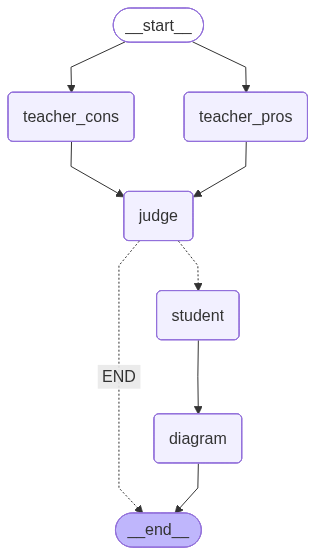

In [33]:
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

graph_builder = StateGraph(State)

graph_builder.add_node("teacher_pros", evaluate_topic_relevant)
graph_builder.add_node("teacher_cons", evaluate_topic_not_relevant)
graph_builder.add_node("judge", judge_topic)
graph_builder.add_node("student", generate_plan_for_topic)
#graph_builder.add_node("image", generate_image)
graph_builder.add_node("diagram", generate_mermaid_diagram)

graph_builder.add_edge(START, "teacher_pros")
graph_builder.add_edge(START, "teacher_cons")
graph_builder.add_edge("teacher_pros", "judge")
graph_builder.add_edge("teacher_cons", "judge")
graph_builder.add_conditional_edges("judge", can_generate_plan, {"student": "student", "END": END})
graph_builder.add_edge("student", "diagram")
#graph_builder.add_edge("image", END)
graph_builder.add_edge("diagram", END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
import uuid
import io
import httpx
import gradio as gr
from PIL import Image as PILImage

def make_thread_id() -> str:
    return str(uuid.uuid4())

async def process_message(message, thread):
    config = {"configurable": {"thread_id": thread}}

    state = {
        "subject": message,
        "pros": [],
        "cons": [],
        "topics": [],
        "is_valid": False,
        "diagram_titles": [],
        "diagram_urls": [],
    }
    result = await graph.ainvoke(state, config=config)

    pros = "\n".join(f"- {p}" for p in result.get("pros", []))
    cons = "\n".join(f"- {c}" for c in result.get("cons", []))
    topics = "\n".join(f"- {t}" for t in result.get("topics", []))
    is_valid = "✅ Oui" if result.get("is_valid") else "❌ Non"
    plan: GrandOralPlan = result.get("plan")

    plan_md = ""
    if plan:
        for part in plan.parts:
            plan_md += f"\n### {part.title} ({part.time})\n{part.content}\n"
            for subpart in part.subparts:
                plan_md += f"\n#### {subpart.title}\n{subpart.content}\n"

    plan_section = f"\n---\n## Plan de l'exposé\n{plan_md}" if plan_md else ""

    markdown = f"""## Évaluation du sujet

**Valide :** {is_valid}

**Arguments pour :**
{pros}

**Arguments contre :**
{cons}

**Éléments du programme :**
{topics}{plan_section}
"""

    gallery_items = []
    titles = result.get("diagram_titles", [])
    urls = result.get("diagram_urls", [])
    async with httpx.AsyncClient(timeout=30) as client:
        for title, url in zip(titles, urls):
            try:
                resp = await client.get(url)
                if resp.status_code == 200:
                    img = PILImage.open(io.BytesIO(resp.content))
                    gallery_items.append((img, title))
            except Exception:
                pass

    return markdown, gallery_items

with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as grand_oral_ui:
    thread = gr.State(make_thread_id())
    gr.Markdown("## Evaluation des sujets de grand oral")
    with gr.Row():
        with gr.Column(scale=2):
            message_output = gr.Markdown("## en attente de sujet à analyser")
        with gr.Column(scale=1):
            diagram_output = gr.Gallery(label="Diagrammes conceptuels", columns=2, show_label=True)
    with gr.Group():
        with gr.Row():
            message = gr.Textbox(show_label=False, placeholder="Entrer le sujet à analyser")
    with gr.Row():
        go_button = gr.Button("Go!", variant="primary")
    message.submit(process_message, [message, thread], [message_output, diagram_output])
    go_button.click(process_message, [message, thread], [message_output, diagram_output])

grand_oral_ui.launch(show_error=True, server_port=7871)


/tmp/ipykernel_3586/1799576856.py:68: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as grand_oral_ui:


* Running on local URL:  http://127.0.0.1:7871
* To create a public link, set `share=True` in `launch()`.


## OpenAI SDK tests

In [35]:
from dotenv import load_dotenv
from agents import Agent, Runner, trace
from agents.mcp import MCPServerStdio
import os
from IPython.display import Markdown, display
from datetime import datetime
load_dotenv(override=True)

True

In [36]:
params = {"command": "npx", "args": ["@playwright/mcp@latest", "--browser", "chromium"]}
async with MCPServerStdio(params=params, client_session_timeout_seconds=30) as server:
    mcp_tools = await server.list_tools()

In [37]:
mcp_tools

[Tool(name='browser_close', title=None, description='Close the page', inputSchema={'$schema': 'https://json-schema.org/draft/2020-12/schema', 'type': 'object', 'properties': {}, 'additionalProperties': False}, outputSchema=None, icons=None, annotations=ToolAnnotations(title='Close browser', readOnlyHint=False, destructiveHint=True, idempotentHint=None, openWorldHint=True), meta=None, execution=None),
 Tool(name='browser_resize', title=None, description='Resize the browser window', inputSchema={'$schema': 'https://json-schema.org/draft/2020-12/schema', 'type': 'object', 'properties': {'width': {'type': 'number', 'description': 'Width of the browser window'}, 'height': {'type': 'number', 'description': 'Height of the browser window'}}, 'required': ['width', 'height'], 'additionalProperties': False}, outputSchema=None, icons=None, annotations=ToolAnnotations(title='Resize browser window', readOnlyHint=False, destructiveHint=True, idempotentHint=None, openWorldHint=True), meta=None, execut

In [38]:
model = "gpt-4o-mini"

In [ ]:
import os
import requests
from agents import Agent, function_tool


@function_tool
def serper_search(query: str) -> str:
    """
    Perform web search using Serper API and return formatted results
    
    Args:
        query: Search query string
        
    Returns:
        Formatted string with search results
    """
    api_key = os.getenv("SERPER_API_KEY")
    
    url = "https://google.serper.dev/search"
    payload = {
        "q": query,
        "num": 10
    }
    headers = {
        "X-API-KEY": api_key,
        "Content-Type": "application/json"
    }
    
    try:
        response = requests.post(url, json=payload, headers=headers, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        # Format results for the agent
        formatted_results = f"Search results for: {query}\n\n"
        
        if "organic" in data:
            for i, item in enumerate(data["organic"][:5], 1):
                title = item.get("title", "")
                snippet = item.get("snippet", "")
                link = item.get("link", "")
                formatted_results += f"{i}. **{title}**\n"
                formatted_results += f"   {snippet}\n"
                formatted_results += f"   Source: {link}\n\n"
        
        if "knowledgeGraph" in data:
            kg = data["knowledgeGraph"]
            formatted_results += f"\n**Key Information:**\n"
            if "description" in kg:
                formatted_results += f"{kg['description']}\n"
        
        return formatted_results if formatted_results else "No results found"
        
    except Exception as e:
        return f"Search failed: {str(e)}"


INSTRUCTIONS = """You are a skilled research analyst specializing in information extraction and synthesis.

**Task**: Given a search term, use the serper_search tool to search the web and produce a concise, high-quality bullet pointssummary.

**Process:**
1. Use the serper_search tool with the search query
2. Analyze the returned results (titles, snippets, links)
3. Create a list of all the important elements from the search results, including key facts, data points, and insights

**Requirements:**
- Focus: Capture key facts, data, and insights
- Style: Succinct and information-dense (no fluff)
- Quality: Prioritize credible sources and recent information
- Format: bullet points listed format, no paragraphs

**What to include:**
- Key facts, statistics, and data points
- Main findings or conclusions
- Important context or background

**What to avoid:**
- Vague generalizations
- Redundant information  
- Marketing language or promotional content
- Personal opinions (yours)
- Unnecessary context or filler

**Output format:**
Provide ONLY the bullet point list. No preambles like "Here's a summary" or "Based on the search".
This summary will be used by another agent to synthesize a comprehensive report."""

search_agent = Agent(
    name="SearchAgent",
    instructions=INSTRUCTIONS,
    tools=[serper_search],
    model=model,
)

In [43]:
request = "quelles sont les contraintes a respecter concernant les élèves pour le grand oral du bac 2026?"

In [46]:
with trace("search_agent"):
    result = await Runner.run(search_agent, request)
display(Markdown(result.final_output))

- **Contexte**: Le Grand Oral du Baccalauréat 2026 est une épreuve qui évalue la capacité des élèves à s'exprimer clairement et à argumenter.
- **Durée de l'épreuve**: 10 minutes de présentation suivies de 10 minutes d'échange avec le jury.
- **Préparation**: Les élèves disposent de 20 minutes pour préparer leur exposé.
- **Choix des questions**: Chaque élève doit définir deux questions basées sur ses enseignements de spécialité; ces questions doivent être claires, précises, et suffisamment ouvertes pour permettre une discussion.
- **Coéficient**: Le Grand Oral a un coefficient de 10 pour le bac général et de 14 pour le bac technologique.
- **Composition du jury**: Composé de deux enseignants, dont un doit être un expert dans le domaine de spécialité de l'élève.
- **Evaluation**: L'épreuve évalue la qualité de l'oral (clarté, engagement, capacité à interagir) mais n'est pas éliminatoire.
- **Importance**: Bien que non éliminatoire, une bonne performance peut significativement influencer la note finale du bac.
- **Préparation recommandée**: S'entraîner à la prise de parole, travailler la posture, le regard et la gestion du temps durant la présentation.

In [ ]:
instructions = "Vous êtes un professeur de lycée de terminale, qui connait parfaitement le programme de mathématiques et de physique chimie de terminale. " \
"Vous avez accès à un navigateur internet pour rechercher des informations récentes sur les contraintes à respecter pour le grand oral du bac 2026. " \
"Votre rôle est de fournir une réponse précise et à jour à la question posée en utilisant les outils à votre disposition, notamment le navigateur internet pour effectuer des recherches approfondies " \
"et trouver les informations les plus récentes concernant les contraintes du grand oral du bac pour l'année 2026."



In [21]:
async with MCPServerStdio(params=params, client_session_timeout_seconds=30) as mcp_server:
    agent = Agent(name="teacher", instructions=instructions, model=model, mcp_servers=[mcp_server])
    with trace("teacher"):
        result = await Runner.run(agent, request, max_turns=20)
    display(Markdown(result.final_output))

Il semble que je rencontre des difficultés à accéder aux informations concernant les contraintes du grand oral pour le bac 2026. Cependant, je peux vous donner un aperçu général des attentes basées sur le cadre habituel pour ce type d'évaluation.

### Contraintes générales pour le grand oral du bac :

1. **Durée de l'épreuve** : Le grand oral doit généralement durer entre 20 et 30 minutes, en incluant le temps de présentation et le temps de questions.

2. **Présentation** : Les élèves doivent préparer une présentation sur un sujet choisi en lien avec leur spécialité, souvent en lien avec des projets ou des thèmes abordés durant l'année.

3. **Dossier de préparation** : Il est souvent requis de soumettre un dossier qui accompagne la présentation, détaillant les recherches et la préparation effectuées.

4. **Questions** : Après la présentation, les examinateurs posent des questions pour évaluer la compréhension et la capacité de l'élève à discuter de son sujet.

5. **Critères d'évaluation** : Les critères d'évaluation peuvent inclure la clarté de l'exposé, la pertinence des arguments, la maîtrise du sujet, ainsi que l'aisance à répondre aux questions.

Pour des informations précises et détaillées, il serait idéal de consulter le site officiel du gouvernement ou les ressources mises à jour par le ministère de l'Éducation Nationale. Vous pourriez essayer de vérifier des sites spécifiques tels que **education.gouv.fr** ou des plateformes dédiées à l'orientation scolaire qui pourraient également publier des informations sur le grand oral en vue du bac 2026.